#Parcial Final IA

###Arbol de desición

Importar librerias

In [ ]:
import pandas as pd
import numpy as np

Cargamos el dataset

In [ ]:
df = pd.read_csv("german_credit_data_updated.csv")

print(df.shape)
df.head()

(954, 11)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


Desripcion del dataset

In [ ]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        954 non-null    int64 
 1   Age               954 non-null    int64 
 2   Sex               954 non-null    object
 3   Job               954 non-null    int64 
 4   Housing           954 non-null    object
 5   Saving accounts   779 non-null    object
 6   Checking account  576 non-null    object
 7   Credit amount     954 non-null    int64 
 8   Duration          954 non-null    int64 
 9   Purpose           954 non-null    object
 10  Credit Risk       954 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 82.1+ KB


,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,175
Checking account,378
Credit amount,0
Duration,0
Purpose,0


Convertimos variable risk

In [ ]:
df['Credit Risk'] = df['Credit Risk'].map({1: 0, 2: 1})

Categorizacion

In [ ]:
target = "Credit Risk"

X = df.drop(target, axis=1)
y = df[target]

Entrenamiento

In [20]:
X = df.drop(target, axis=1)
X = pd.get_dummies(X, columns=['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], drop_first=True)

for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Arbol de descisión

In [21]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Predicción

In [22]:
y_pred_dt = dt.predict(X_test)

Metricas

In [23]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

print("\nReporte:")
print(classification_report(y_test, y_pred_dt))

print("\nMatriz:")
print(confusion_matrix(y_test, y_pred_dt))

Accuracy:
0.6387434554973822

Reporte:
              precision    recall  f1-score   support

           0       0.69      0.84      0.76       128
           1       0.42      0.24      0.30        63

    accuracy                           0.64       191
   macro avg       0.55      0.54      0.53       191
weighted avg       0.60      0.64      0.61       191


Matriz:
[[107  21]
 [ 48  15]]


##EDA
Los datos nos indican que hay 128 registros de buen cliente (variable Risk = 0)
y tenemos 63 registros de incumplimiento (varible risk = 1)
con un Accurracy de 0.64 lo cual es muy baja la precision de este analisis.
Tambien tenemos una matriz de confusion con 107 verdaderos positivos, 21 falsos positivos, 48 falsos negativos y 15 verdaderos negativos. Esto con un solo arbol de desición.

Visualización del arbol

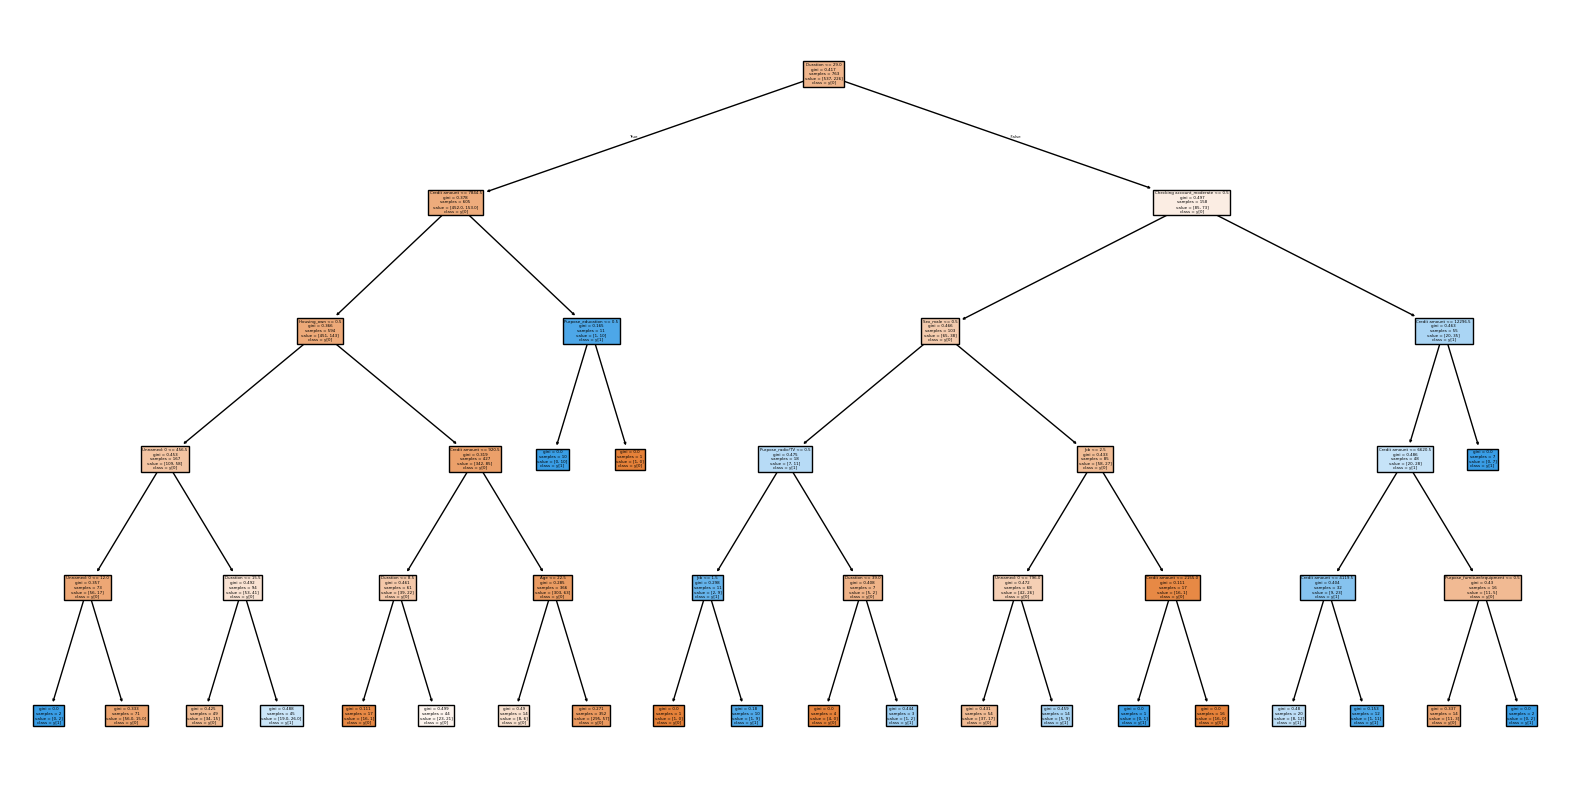

In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(
    dt,
    filled=True,
    feature_names=X.columns,
    class_names=True
)

plt.show()

##Random Forest

Entrenamos y escojemos cuantos arboles de desicion crearemos en este caso solo 100

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, random_state=42)

Metricas

In [ ]:
y_pred_rf = rf.predict(X_test)

print("Accuracy RF:")
print(accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy RF:
0.6910994764397905
              precision    recall  f1-score   support

           0       0.69      0.98      0.81       128
           1       0.75      0.10      0.17        63

    accuracy                           0.69       191
   macro avg       0.72      0.54      0.49       191
weighted avg       0.71      0.69      0.60       191



Analicé la estructura del modelo. Evalué el desempeño Accuracy. Precision, Recall y F1.

Verificamos la importacia de las caracteristicas

In [25]:
feature_importance_df = pd.DataFrame( {"Features": list(X.columns), "importance": rf.feature_importances_}).sort_values("importance", ascending=False)
feature_importance_df

,Features,importance
3,Credit amount,0.227200
4,Duration,0.177426
1,Age,0.130757
0,Unnamed: 0,0.122252
6,Housing_own,0.057808
11,Checking account_moderate,0.050652
2,Job,0.037694
17,Purpose_radio/TV,0.031763
5,Sex_male,0.031011
7,Housing_rent,0.023622


Graficamos la importancia de las caracterisiticas.

(array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25]),
 [Text(0.0, 0, '0.00'),
  Text(0.05, 0, '0.05'),
  Text(0.1, 0, '0.10'),
  Text(0.15000000000000002, 0, '0.15'),
  Text(0.2, 0, '0.20'),
  Text(0.25, 0, '0.25')])

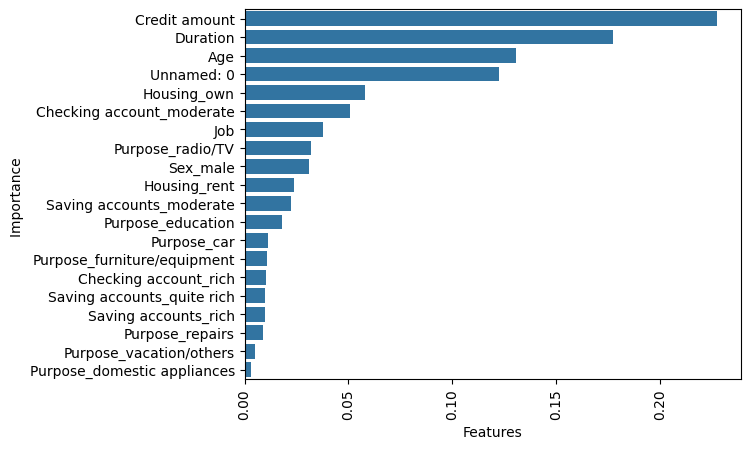

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(y = feature_importance_df.Features , x = feature_importance_df.importance )
plt.xlabel('Features')
plt.ylabel("Importance ")
plt.xticks(rotation = 90 )

##Factores más determinantes del riesgo crediticio.
Los factores que determinan si un cliente de la entidad finaciera es cumplido con sus pagos son los siguientes:

*   Monto del credito
*   Duracion del credito
*   Edad del cliente
*   Si tiene vivienda propia



Matriz de confusion.

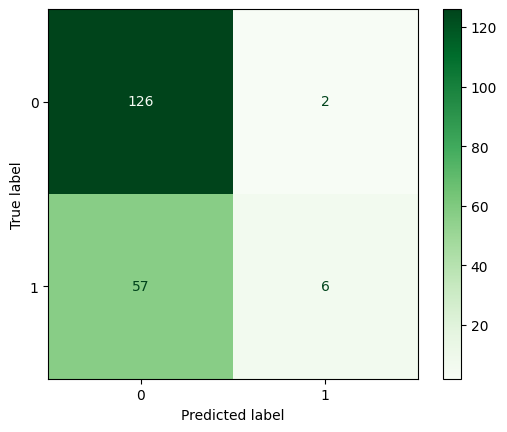

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred_rf)
display = ConfusionMatrixDisplay(confusion_matrix= cm )
display.plot(cmap="Greens")

El analisis con random forest nos indica que hay 128 registros de buen cliente (variable Risk = 0) y tenemos 63 registros de incumplimiento (varible risk = 1) con un Accurracy de 0.64 lo cual es muy baja la precision de este analisis. Tambien tenemos una matriz de confusion realizada con los resultados del Random Forest con 126 verdaderos positivos, 2 falsos positivos, 57 falsos negativos y 6 verdaderos negativos.
Concluimos que a diferencia de un solo arbol de decision la matriz de confusion tiende a mostrar resultados diferentes.